In [1]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns
from IPython.display import display

In [2]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("meat\\"):
    sub_folder_files = os.listdir(os.path.join("meat\\", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("meat\\", sub_folder, filename)
        img = cv.imread(img_path)
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(filename)[0]
        file_name.append(filename)
        
data = np.array(data)
labels = np.array(labels)

In [3]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
	pass

In [4]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  2000
Data setelah augmentasi:  0


In [5]:
def otsu_scratch(img):
    hist, _ = np.histogram(img.flatten(), 256, [0,256])
    total = img.size
    current_max, threshold = 0, 0
    sum_total = np.dot(np.arange(256), hist)
    
    sum_B, weight_B = 0, 0
    for i in range(256):
        weight_B += hist[i]
        if weight_B == 0: continue
        weight_F = total - weight_B
        if weight_F == 0: break
        
        sum_B += i * hist[i]
        mB = sum_B / weight_B
        mF = (sum_total - sum_B) / weight_F
        
        var_between = weight_B * weight_F * (mB - mF) ** 2
        if var_between > current_max:
            current_max = var_between
            threshold = i
            
    return np.where(img >= threshold, 255, 0).astype(np.uint8)

kernel_3x3 = np.ones((3, 3), dtype=np.uint8)
kernel_5x5 = np.ones((5, 5), dtype=np.uint8)

def pad_image(img, pad_size):
    return np.pad(img, pad_size, mode='edge')

def erosi_grayscale(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    img_padded = pad_image(img, ((pad_h, pad_h), (pad_w, pad_w)))
    result = np.zeros_like(img)
    
    for i in range(h):
        for j in range(w):
            # Ambil region of interest (ROI) sewarna kernel
            roi = img_padded[i:i+kh, j:j+kw]
            result[i, j] = np.min(roi)
            
    return result

def dilasi_grayscale(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    img_padded = pad_image(img, ((pad_h, pad_h), (pad_w, pad_w)))
    result = np.zeros_like(img)
    
    for i in range(h):
        for j in range(w):
            roi = img_padded[i:i+kh, j:j+kw]
            result[i, j] = np.max(roi)
            
    return result

def opening_grayscale(img, kernel):
    return dilasi_grayscale(erosi_grayscale(img, kernel), kernel)

def closing_grayscale(img, kernel):
    return erosi_grayscale(dilasi_grayscale(img, kernel), kernel)

# --- 7. BITWISE AND ---
def bitwise_and_scratch(img, mask):
    return np.where(mask > 0, img, 0).astype(np.uint8)

# --- FUNGSI RESIZE (Diizinkan pakai cv2 sesuai prompt) ---
def resize(image, target_size=(128, 128)):
    return cv.resize(image, target_size, interpolation=cv.INTER_AREA)

In [6]:
def extract_and_evaluate(processed_data, labels_data, experiment_name):
    # 1. Ekstraksi GLCM
    features = []
    for img in processed_data:
        feat_row = []
        for angle in [0, 45, 90, 135]:
            g = glcm(img, angle)
            feat_row.extend([
                contrast(g), correlation(g), energy(g), 
                homogenity(g), ASM(g), entropyGlcm(g), dissimilarity(g)
            ])
        features.append(feat_row)
        
    cols = []
    for angle in [0, 45, 90, 135]:
        cols.extend([
            f'Contrast{angle}', f'Correlation{angle}', f'Energy{angle}',
            f'Homogeneity{angle}', f'ASM{angle}', f'Entropy{angle}', f'Dissimilarity{angle}'
        ])
        
    df_features = pd.DataFrame(features, columns=cols)
    
    # 2. Train-Test Split (80/20) - Konsisten
    X_train, X_test, y_train, y_test = train_test_split(
        df_features, labels_data, test_size=0.2, random_state=42
    )
    
    # 3. Normalisasi Mean-Std
    X_train_mean, X_train_std = X_train.mean(), X_train.std()
    X_train = (X_train - X_train_mean) / X_train_std
    X_test = (X_test - X_train_mean) / X_train_std
    
    # 4. Pelatihan Model
    models = {
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'SVM': SVC(kernel='rbf', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=5, random_state=42)
    }
    
    accuracies = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracies[name] = accuracy_score(y_test, y_pred)
        
    return accuracies

def show_samples(images, title):
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    fig.suptitle(title, fontsize=14)
    for i, ax in enumerate(axes):
        ax.imshow(images[i], cmap='gray')
        ax.axis('off')
    plt.show()

In [7]:
# --- PERBAIKAN: Isi list dataPreprocessed ---
dataPreprocessed = []

for i in range(len(data)): 
    # Karena data di awal sudah diubah ke grayscale saat di-load, 
    # kita cukup memasukkannya langsung ke dalam dataPreprocessed
    img_processed = data[i]
    
    # Masukkan ke dalam list agar tidak kosong
    dataPreprocessed.append(img_processed)

print("Total citra yang siap diekstrak GLCM:", len(dataPreprocessed)) 
# Pastikan print di atas memunculkan angka 300!

Total citra yang siap diekstrak GLCM: 2000


In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [9]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [10]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [11]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [12]:
for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [13]:
for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [14]:
for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [15]:
for i in range(len(dataPreprocessed)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [16]:
for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [17]:
for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Menjalankan Eksperimen 3 (Otsu + Opening + Bitwise AND)...


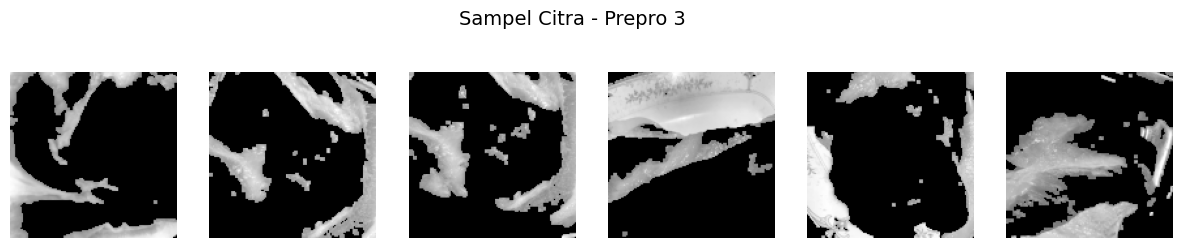

Eksperimen 3 selesai.

=== Tabel Akurasi Singel Skenario (Prepro 3) ===


,Model,Akurasi Prepro 3 (%)
0,K-Nearest Neighbors (KNN),93.50
1,Support Vector Machine (SVM),95.25
2,Random Forest,93.75


In [19]:
comparison_results = []

def prepro3():
    print("Menjalankan Eksperimen 3 (Otsu + Opening + Bitwise AND)...")
    processed_imgs = []
    for img in data:
        img_resized = resize(img, (128, 128))
        # 1. Otsu Thresholding (Scratch)
        mask = otsu_scratch(img_resized)
        # 2. Morphology Opening (Scratch)
        clean_mask = opening_grayscale(mask, kernel_3x3)
        # 3. Bitwise AND (Scratch)
        segmented = bitwise_and_scratch(img_resized, clean_mask)
        processed_imgs.append(segmented)
        
    show_samples(processed_imgs[:6], "Sampel Citra - Prepro 3")
    acc = extract_and_evaluate(processed_imgs, labels, "Prepro 3")
    
    comparison_results.append({'Eksperimen': 'Prepro 3', **acc})
    print("Eksperimen 3 selesai.\n")

prepro3()

if len(comparison_results) > 0:
    df_raw = pd.DataFrame(comparison_results)
    
    # 2. Ambil nama skenario eksperimen yang aktif di file ini
    nama_eksperimen = df_raw['Eksperimen'].iloc[0] 
    
    # 3. Ambil data model secara manual untuk dibentuk vertikal secara presisi
    data_vertikal = {
        'Model': [
            'K-Nearest Neighbors (KNN)', 
            'Support Vector Machine (SVM)', 
            'Random Forest'
        ],
        f'Akurasi {nama_eksperimen} (%)': [
            f"{df_raw['KNN'].iloc[0]*100:.2f}",
            f"{df_raw['SVM'].iloc[0]*100:.2f}",
            f"{df_raw['Random Forest'].iloc[0]*100:.2f}"
        ]
    }
    
    # 4. Ubah menjadi DataFrame siap tampil
    df_final = pd.DataFrame(data_vertikal)
    
    print(f"=== Tabel Akurasi Singel Skenario ({nama_eksperimen}) ===")
    display(df_final)
else:
    print("⚠️ Error: Data 'comparison_results' kosong. Pastikan fungsi eksperimen sudah dipanggil sebelum bagian ini!")

In [20]:
# 1. Pastikan semua list penampung dalam keadaan kosong kembali
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

# 2. SATUKAN SEMUA LOOPING DI SINI (Gunakan len(dataPreprocessed))
for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

In [21]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,FreshMeat,10.573662,23.760557,14.914359,23.789496,0.442846,0.352479,0.433537,0.336144,...,0.001247,0.000848,0.035421,0.030360,0.035318,0.029118,0.996442,0.991965,0.994976,0.991955
1,0002.jpg,FreshMeat,67.551755,98.546506,64.706551,114.667301,0.267247,0.213515,0.253086,0.199027,...,0.000486,0.000367,0.022262,0.019499,0.022043,0.019153,0.976865,0.966163,0.977810,0.960627
2,0003.jpg,FreshMeat,54.792487,100.276557,65.420824,95.565899,0.285306,0.209725,0.252534,0.208749,...,0.000462,0.000371,0.022857,0.019061,0.021497,0.019262,0.980217,0.963729,0.976367,0.965434
3,0004.jpg,FreshMeat,33.929582,74.889987,48.781128,64.485911,0.440273,0.342280,0.404675,0.346542,...,0.000763,0.000590,0.029634,0.024154,0.027621,0.024280,0.995909,0.990961,0.994108,0.992217
4,0005.jpg,FreshMeat,141.941253,207.162828,146.965883,250.130120,0.211750,0.176970,0.221433,0.164476,...,0.000325,0.000230,0.017663,0.015897,0.018018,0.015162,0.973578,0.961381,0.972666,0.953372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0996.jpg,RottenMeat,162.292945,234.291108,94.158208,224.849476,0.200523,0.163550,0.257664,0.163208,...,0.000327,0.000182,0.015169,0.013505,0.018079,0.013475,0.974715,0.963441,0.985319,0.964915
1996,0997.jpg,RottenMeat,171.344213,342.921695,221.082466,353.164076,0.208251,0.133238,0.168520,0.132166,...,0.000195,0.000155,0.016184,0.012451,0.013966,0.012430,0.967269,0.934351,0.957953,0.932390
1997,0998.jpg,RottenMeat,218.441688,296.820885,115.921930,285.501751,0.169852,0.135150,0.213170,0.136282,...,0.000270,0.000159,0.014055,0.012564,0.016439,0.012608,0.958093,0.942955,0.977770,0.945131
1998,0999.jpg,RottenMeat,130.975249,199.614719,100.651240,211.176130,0.216074,0.164958,0.219753,0.162838,...,0.000242,0.000170,0.015220,0.013085,0.015542,0.013050,0.979046,0.968043,0.983900,0.966193


<Axes: >

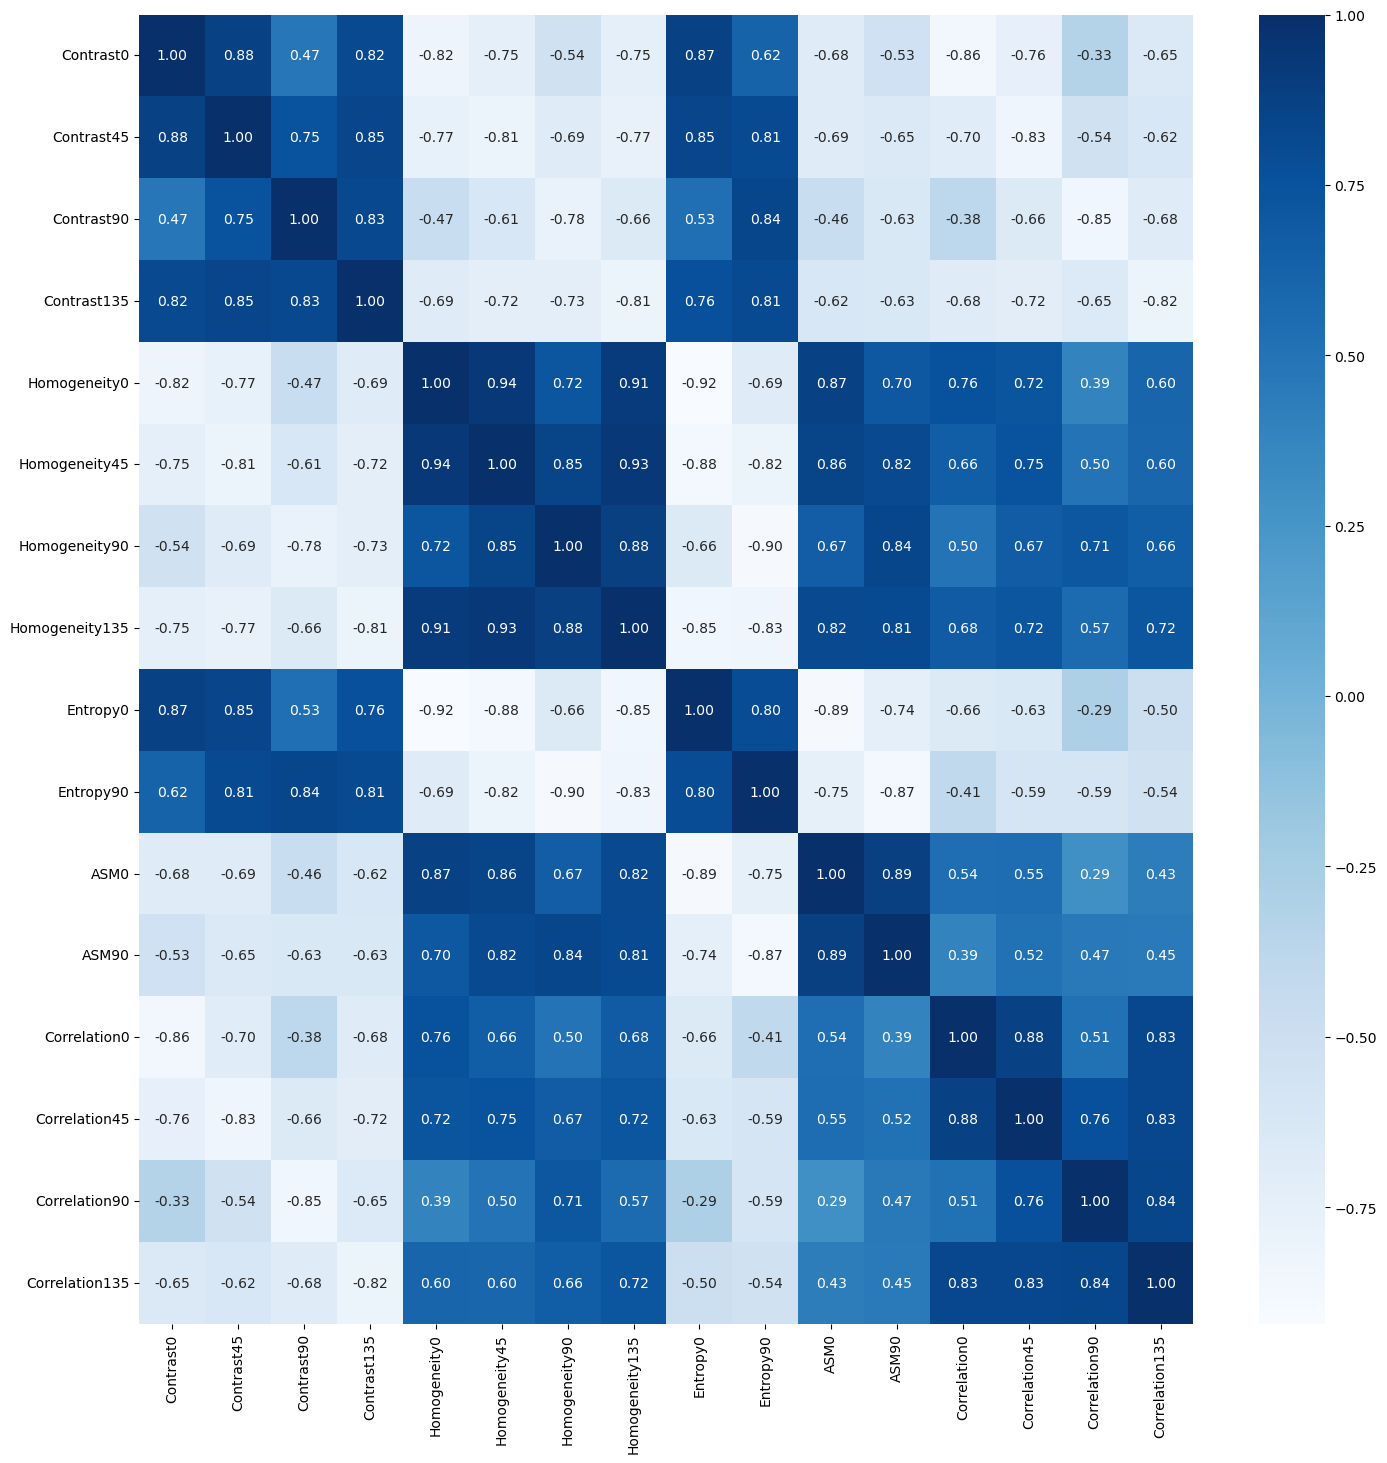

In [22]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [23]:
# ubah bagian test_size sesuai kebutuhan
# 0.3 = 30% data untuk testing (train/test 70/30)
# 0.2 = 20% data untuk testing (train/test 80/20)
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

# normalisasi mean std
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

(1600, 16)
(400, 16)


In [24]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [25]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.99      0.99      0.99       801
  RottenMeat       0.99      0.99      0.99       799

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600

[[795   6]
 [  6 793]]
Accuracy: 0.9925

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.89      0.88      0.89       199
  RottenMeat       0.89      0.90      0.89       201

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400

[[176  23]
 [ 21 180]]
Accuracy: 0.89


In [26]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.90      0.93      0.92       801
  RottenMeat       0.93      0.90      0.91       799

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600

[[748  53]
 [ 82 717]]
Accuracy: 0.915625

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.91      0.93      0.92       199
  RottenMeat       0.93      0.91      0.92       201

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

[[186  13]
 [ 19 182]]
Accuracy: 0.92


In [27]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

   FreshMeat       0.91      0.97      0.94       801
  RottenMeat       0.97      0.90      0.93       799

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600

[[776  25]
 [ 77 722]]
Accuracy: 0.93625

------Testing Set------
              precision    recall  f1-score   support

   FreshMeat       0.86      0.92      0.89       199
  RottenMeat       0.91      0.85      0.88       201

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400

[[183  16]
 [ 31 170]]
Accuracy: 0.8825


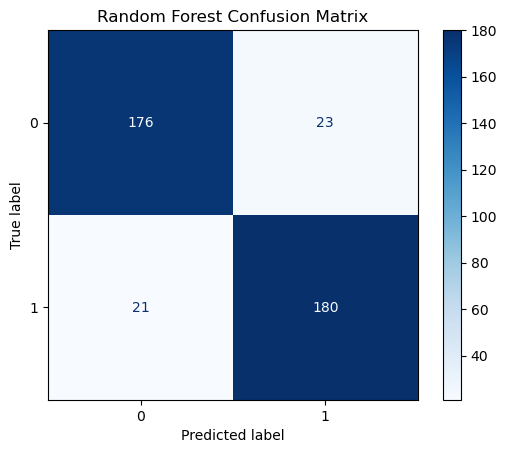

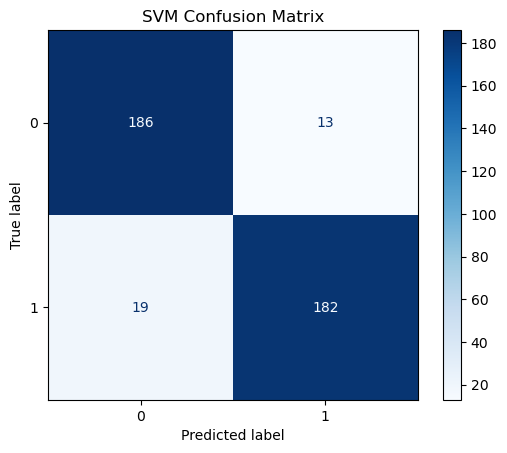

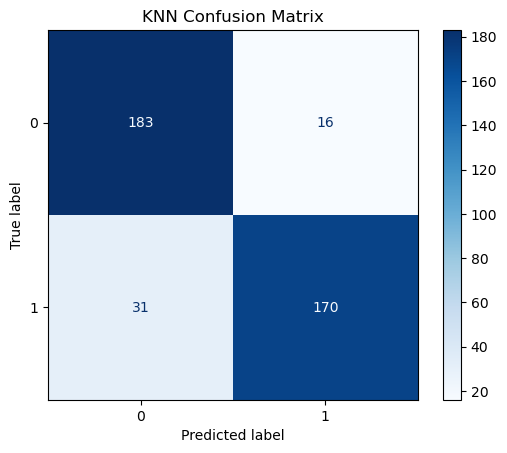

In [28]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")